# Validación de la receta de ruido vs Hourglass

**Objetivo**: dado un row de `hourglass_photometry.parquet`, predecir `fluxcal_err` (σ que reporta Hourglass) usando solamente:
- `sim_mag_obs` (magnitud del modelo, sin ruido)
- `psf_nea`, `sky_sig`, `read_noise`, `zp` (parámetros del simlib por fila)

**Receta** (de `kilonova_syntetic.apply_roman_noise`, en unidades fluxcal con `ZP_SNANA=27.5`):

```
F_sim               = 10^((27.5 − sim_mag_obs)/2.5)              [fcal]
flux_calibrated(zp) = 10^((27.5 − zp)/2.5)                       [fcal/e⁻]

σ²_pred = flux_calibrated(zp) · F_sim                            ← Poisson fuente
        + nea · (sky_sig² + read_noise²) · flux_calibrated(zp)²  ← fondo + lectura
```

El `fluxcal_err` de Hourglass incluye además ruido del **host** (sky+galaxy+source). La receta NO. Por lo tanto:
- `σ_pred / fluxcal_err ≤ 1`
- mediana esperada ≈ 0.986 (según docstring de `kilonova_syntetic.py`)
- cola en p05 ≈ 0.65 en F/H DEEP (donde el host pesa más)

Si esto se reproduce, la receta sin host es la cota inferior consistente para generar KN sintéticas comparables a SN de Hourglass.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_ROOT = Path("/Volumes/Elements/kn_sn_bundle")
SN_DIR    = DATA_ROOT / "sn"
PHOT_PATH = SN_DIR / "hourglass_photometry.parquet"
OBJ_PATH  = SN_DIR / "hourglass_objects.parquet"

ZP_SNANA = 27.5
SNANA_SENTINEL = 60.0   # sim_mag_obs=60 → fila sin simulación

# Mapeo banda → survey (en Hourglass cada banda pertenece a un solo modo de
# observación: WIDE cubre R/Z, DEEP cubre H/F; Y y J aparecen en ambos).
BAND_SURVEY = {"R": "WIDE", "Z": "WIDE", "H": "DEEP", "F": "DEEP"}

assert PHOT_PATH.exists(), f"No existe: {PHOT_PATH}"
assert OBJ_PATH.exists(),  f"No existe: {OBJ_PATH}"
print(f"OK: {PHOT_PATH}")
print(f"OK: {OBJ_PATH}")

OK: /Volumes/Elements/kn_sn_bundle/sn/hourglass_photometry.parquet
OK: /Volumes/Elements/kn_sn_bundle/sn/hourglass_objects.parquet


## Paso 1 — Cargar el parquet

Solo las columnas necesarias para el test (lectura más rápida).

In [35]:
cols = ["cid", "mjd", "band", "fluxcal", "fluxcal_err",
        "psf_nea", "sky_sig", "read_noise", "zp", "sim_mag_obs"]
phot = pd.read_parquet(PHOT_PATH)#, columns=cols)
obj = pd.read_parquet(OBJ_PATH)#, columns=cols)

print(f"Filas totales: {len(phot):,}")
phot.head()
obj.head()

Filas totales: 11,042,803


,field,class,sub_class,z_cmb,ra,dec,mw_ebv,peak_mjd,snr_max_Y,snr_max_J,peak_mag_Y,peak_mag_J,n_obs,t_rest_min,t_rest_max,scone_prob_Ia,cid
0,WIDE+WIDE-PRISM,AGN,AGN,1.55960,150.12979,2.50898,0.016329,61800.0,35.87140,38.24560,21.6773,21.9512,584,78.1371,361.803,NaN,280002
1,WIDE+WIDE-PRISM,AGN,AGN,1.92421,150.13977,2.48339,0.015874,61800.0,11.37930,6.07564,23.2511,23.3919,584,68.3946,316.692,NaN,280005
2,WIDE+WIDE-PRISM,AGN,AGN,1.44062,34.37314,-5.14197,0.021260,61800.0,23.50640,4.72386,22.1324,21.8958,584,81.8787,379.002,NaN,280007
3,WIDE+WIDE-PRISM,AGN,AGN,1.04326,53.11078,-27.76802,0.007200,61800.0,NaN,NaN,22.0535,22.2683,584,97.8449,452.707,NaN,280008
4,WIDE,AGN,AGN,1.56770,53.10323,-27.70930,0.007875,61800.0,6.00177,17.12050,20.5214,20.5421,584,77.8606,360.244,NaN,280014


## Paso 2 — Filtrar filas válidas

Descarto:
- `sim_mag_obs == 99` → centinela SNANA (no hubo simulación esa noche)
- `fluxcal_err <= 0` → fila inválida

**No** filtro por `fluxcal > 0` ni por SNR — el test es sobre σ, no sobre detección. La receta predice σ a partir del flujo *verdadero* (`sim_mag_obs`), así que vale igual para no-detecciones.

In [5]:
phot['magcal'] = 27.5 - 2.5*np.log10(phot['fluxcal'])
mask = (phot["sim_mag_obs"] != 99) & (phot["fluxcal_err"] > 0)
df = phot.loc[mask].copy()
print(f"Filas válidas: {len(df):,}  ({100*len(df)/len(phot):.1f}%)")
print("\nObs por banda:")
print(df["band"].value_counts().sort_index())

/opt/anaconda3/envs/kilonova/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Filas válidas: 8,969,623  (81.2%)

Obs por banda:
band
F     636621
H     696870
J    2372853
R    1228270
Y    2394106
Z    1640903
Name: count, dtype: int64


## Paso 2b — Distribución de parámetros fotométricos

Histogramas de las 8 variables que entran a la receta (o que caracterizan el sample). `mw_ebv` viene del parquet de objetos y se une por `cid`. Los parámetros de simlib (`psf_nea`, `read_noise`) tienen pocos valores únicos (uno por banda/tier), por eso aparecen como picos discretos.

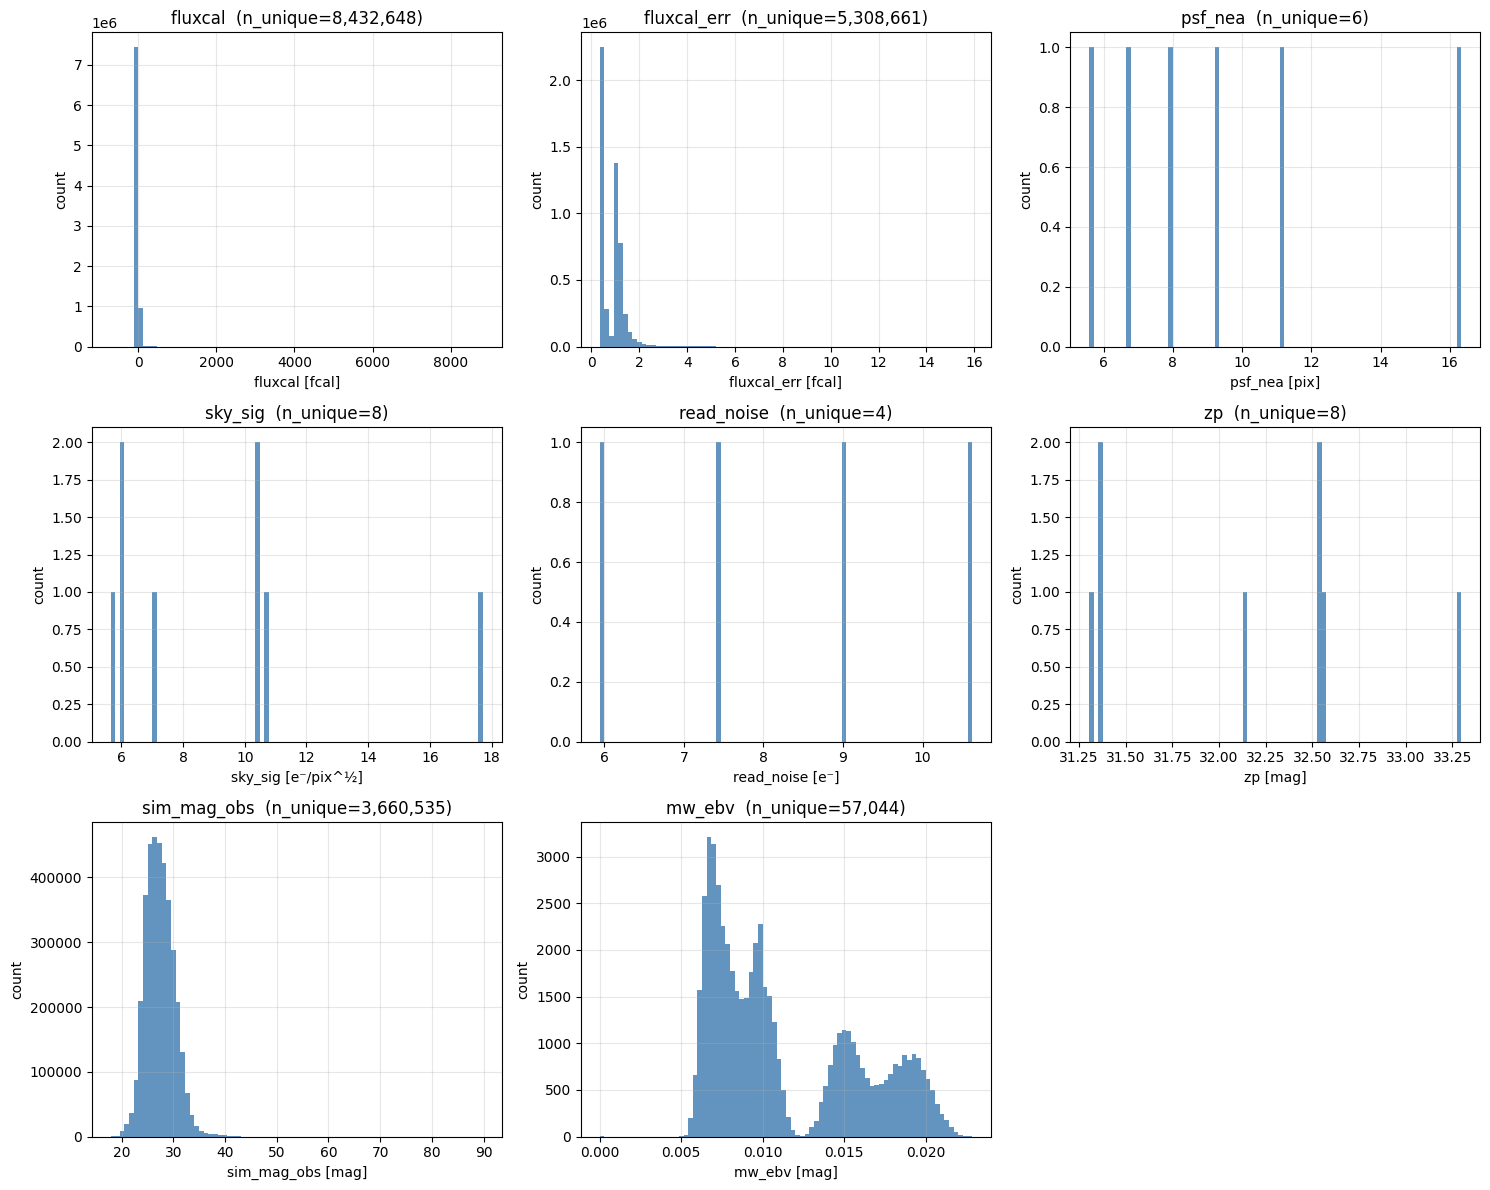

In [6]:
vars_cfg = [
    ("fluxcal",     df["fluxcal"].unique(),                   "fluxcal [fcal]"),
    ("fluxcal_err", df["fluxcal_err"].unique(),               "fluxcal_err [fcal]"),
    ("psf_nea",     df["psf_nea"].unique(),                   "psf_nea [pix]"),
    ("sky_sig",     df["sky_sig"].unique(),                   "sky_sig [e⁻/pix^½]"),
    ("read_noise",  df["read_noise"].unique(),                "read_noise [e⁻]"),
    ("zp",          df["zp"].unique(),                        "zp [mag]"),
    ("sim_mag_obs", df["sim_mag_obs"].unique(),               "sim_mag_obs [mag]"),
    ("mw_ebv",      obj["mw_ebv"].dropna().unique(),          "mw_ebv [mag]"),
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, (col, vals, label) in zip(axes.flat, vars_cfg):
    ax.hist(vals, bins=80, color="steelblue", edgecolor="none", alpha=0.85)
    ax.set_xlabel(label)
    ax.set_ylabel("count")
    ax.set_title(f"{col}  (n_unique={len(vals):,})")
    ax.grid(alpha=0.3)

axes.flat[-1].set_visible(False)
plt.tight_layout()
plt.show()

## Paso 2c — Simulador de observaciones: mag_model → fluxcal con ruido

Convierte una magnitud de modelo (sin ruido, **sin** extinción MW) en un `fluxcal` simulado.

**Pipeline implementado** (sin host, igual que la decisión del CLAUDE.md):

```
mag_model                                       ← Bulla grid, post-redshift, pre-extinción
  + A_λ · mw_ebv   [Fitzpatrick 1999, R_V=3.1]       → mag_ext
  → F_sim = 10^((27.5 − mag_ext)/2.5)                 → flujo verdadero [fcal]
  zp_obs = zp + N(0, zp_sig)   [Rose+2025 eq 8, σ=0.15 mag]
  → σ_pred (receta noise, sin host)                   → incertidumbre [fcal]
  → fluxcal = F_sim + N(0, σ_pred)                    → observación simulada
```

**Cuándo usar `zp_sig`**:
- `zp_sig=0.15` (default) → `zp` es un valor nominal (e.g., Table 3 de Rose+2025). La función añade el scatter FOV internamente.
- `zp_sig=0.0` → `zp` ya viene muestreado del parquet de Hourglass, que lleva el scatter absorbido.

**Nota de validación**: en Hourglass, `sim_mag_obs` ya incluye la extinción MW. Para validar aquí se pasa `mw_ebv=0` y `zp_sig=0.0` (parquet).

In [ ]:
# A_lambda / E(B-V) — Fitzpatrick 1999, R_V=3.1, Cardelli+O'Donnell parameterization
# computed at effective wavelengths of Roman WFI filters
MW_EXT = {
    "R": 2.71,  # F062, λ_eff ≈ 0.620 μm
    "Z": 1.34,  # F087, λ_eff ≈ 0.869 μm
    "Y": 1.14,  # F106, λ_eff ≈ 1.060 μm
    "J": 0.83,  # F129, λ_eff ≈ 1.293 μm
    "H": 0.60,  # F158, λ_eff ≈ 1.577 μm
    "F": 0.47,  # F184, λ_eff ≈ 1.842 μm
}

# ZP scatter per-exposure: σ=0.15 mag (Rose+2025 eq 8, FOV-dependent).
# Already absorbed in parquet's zp column — only apply when using nominal ZP.
ZP_SCATTER = 0.15





# Aplicar sobre todo df con zp_sig=0 (parquet ya tiene scatter absorbido)
fc_sim, fc_err_sim = simulate_fluxcal(
    mag_model  = df["sim_mag_obs"].values,
    mw_ebv     = np.zeros(len(df)),
    band       = df["band"].values,
    nea        = df["psf_nea"].values,
    sky_sig    = df["sky_sig"].values,
    read_noise = df["read_noise"].values,
    zp         = df["zp"].values,
    zp_sig     = 0.0,
    rng        = np.random.default_rng(42),
)

df["fluxcal_sim"]     = fc_sim
df["fluxcal_err_sim"] = fc_err_sim
df["mag_sim"]         = ZP_SNANA - 2.5 * np.log10(np.where(fc_sim > 0, fc_sim, np.nan))
df["mag_hg"]          = ZP_SNANA - 2.5 * np.log10(np.where(df["fluxcal"] > 0, df["fluxcal"], np.nan))

print(f"Columnas agregadas: fluxcal_sim, fluxcal_err_sim, mag_sim, mag_hg")
print(f"Filas con fluxcal_sim > 0: {(df['fluxcal_sim'] > 0).sum():,} / {len(df):,}")

Columnas agregadas: fluxcal_sim, fluxcal_err_sim, mag_sim, mag_hg
Filas con fluxcal_sim > 0: 7,965,547 / 8,969,623


## Paso 2d — Curvas de luz: Hourglass vs simulado

Comparación por objeto de la magnitud observada (Hourglass, con ruido real + host) y la magnitud simulada (nuestra receta, sin host). Cada panel = un objeto, cada color = una banda.

In [43]:
BAND_COLOR = {"R": "C0", "Z": "C1", "Y": "C2", "J": "C3", "H": "C4", "F": "C5"}

TARGET_CLASS = "SN_Ia"  # cambiar aquí según las clases disponibles (ver print abajo)

df_obj = df.merge(obj[["cid", "class", "peak_mjd","field"]], on="cid", how="left")

print("Clases and field disponibles con detecciones:")
print(df_obj[df_obj["mag_hg"].notna()].drop_duplicates(subset="cid")["class"].value_counts().to_string())
print(df_obj[df_obj["mag_hg"].notna()].drop_duplicates(subset="cid")["field"].value_counts().to_string())

print()

Clases and field disponibles con detecciones:
class
CCSN         39177
SN_Ia        21731
SN_Iax        1318
SNIa-91bg     1317
Fixed_mag      489
AGN            139
SLSN-I          69
TDE             39
ILOT            35
PISN            15
KN              14
field
WIDE               37583
DEEP               13834
WIDE+WIDE-PRISM     8024
DEEP+DEEP-PRISM     4902



In [63]:
detected

,cid,mjd,band,phot_flag,fluxcal,fluxcal_err,psf_nea,sky_sig,read_noise,zp,zp_err,sim_mag_obs,magcal,fluxcal_sim,fluxcal_err_sim,mag_sim,mag_hg,class,peak_mjd,field
5662352,114,62240.0,Z,0,1.191503,0.956753,6.695,5.648,10.624,31.302999,0.15,33.990620,27.309763,0.616448,0.937632,28.025259,27.309763,SN_Ia,62282.096,WIDE
5662354,114,62240.0,J,0,2.516999,1.099193,9.210,6.017,10.624,31.354000,0.15,29.594400,26.497793,0.136070,1.066666,29.665595,26.497793,SN_Ia,62282.096,WIDE
5662356,114,62245.0,Y,0,1.265693,1.002061,7.895,6.000,10.624,31.356001,0.15,28.516996,27.244179,1.925055,0.988982,26.788892,27.244179,SN_Ia,62282.096,WIDE
5662358,114,62250.0,Z,0,0.615250,0.947641,6.695,5.648,10.624,31.302999,0.15,28.736246,28.027370,0.451556,0.942721,28.363221,28.027370,SN_Ia,62282.096,WIDE
5662360,114,62250.0,J,0,1.078926,1.080233,9.210,6.017,10.624,31.354000,0.15,27.441664,27.417521,2.351408,1.078852,26.571680,27.417521,SN_Ia,62282.096,WIDE
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8967184,42330,62655.0,Y,0,3.294647,1.194559,7.895,6.000,10.624,31.356001,0.15,26.260765,26.205479,1.973177,1.027934,26.762085,26.205479,SN_Ia,62469.621,WIDE
8967185,42330,62655.0,J,0,0.378110,1.364187,9.210,6.017,10.624,31.354000,0.15,26.807110,28.555954,0.877203,1.089953,27.642250,28.555954,SN_Ia,62469.621,WIDE
8967187,42330,62660.0,Z,0,1.304996,1.049474,6.695,5.648,10.624,31.302999,0.15,29.263992,27.210978,1.234737,0.940750,27.271064,27.210978,SN_Ia,62469.621,WIDE
8967188,42330,62660.0,Y,0,3.550249,1.197624,7.895,6.000,10.624,31.356001,0.15,26.263411,26.124353,2.241104,1.027828,26.623845,26.124353,SN_Ia,62469.621,WIDE


clase=SN_Ia  cid=30440  bandas=['J', 'R', 'Y', 'Z']  peak_mjd=62227.1


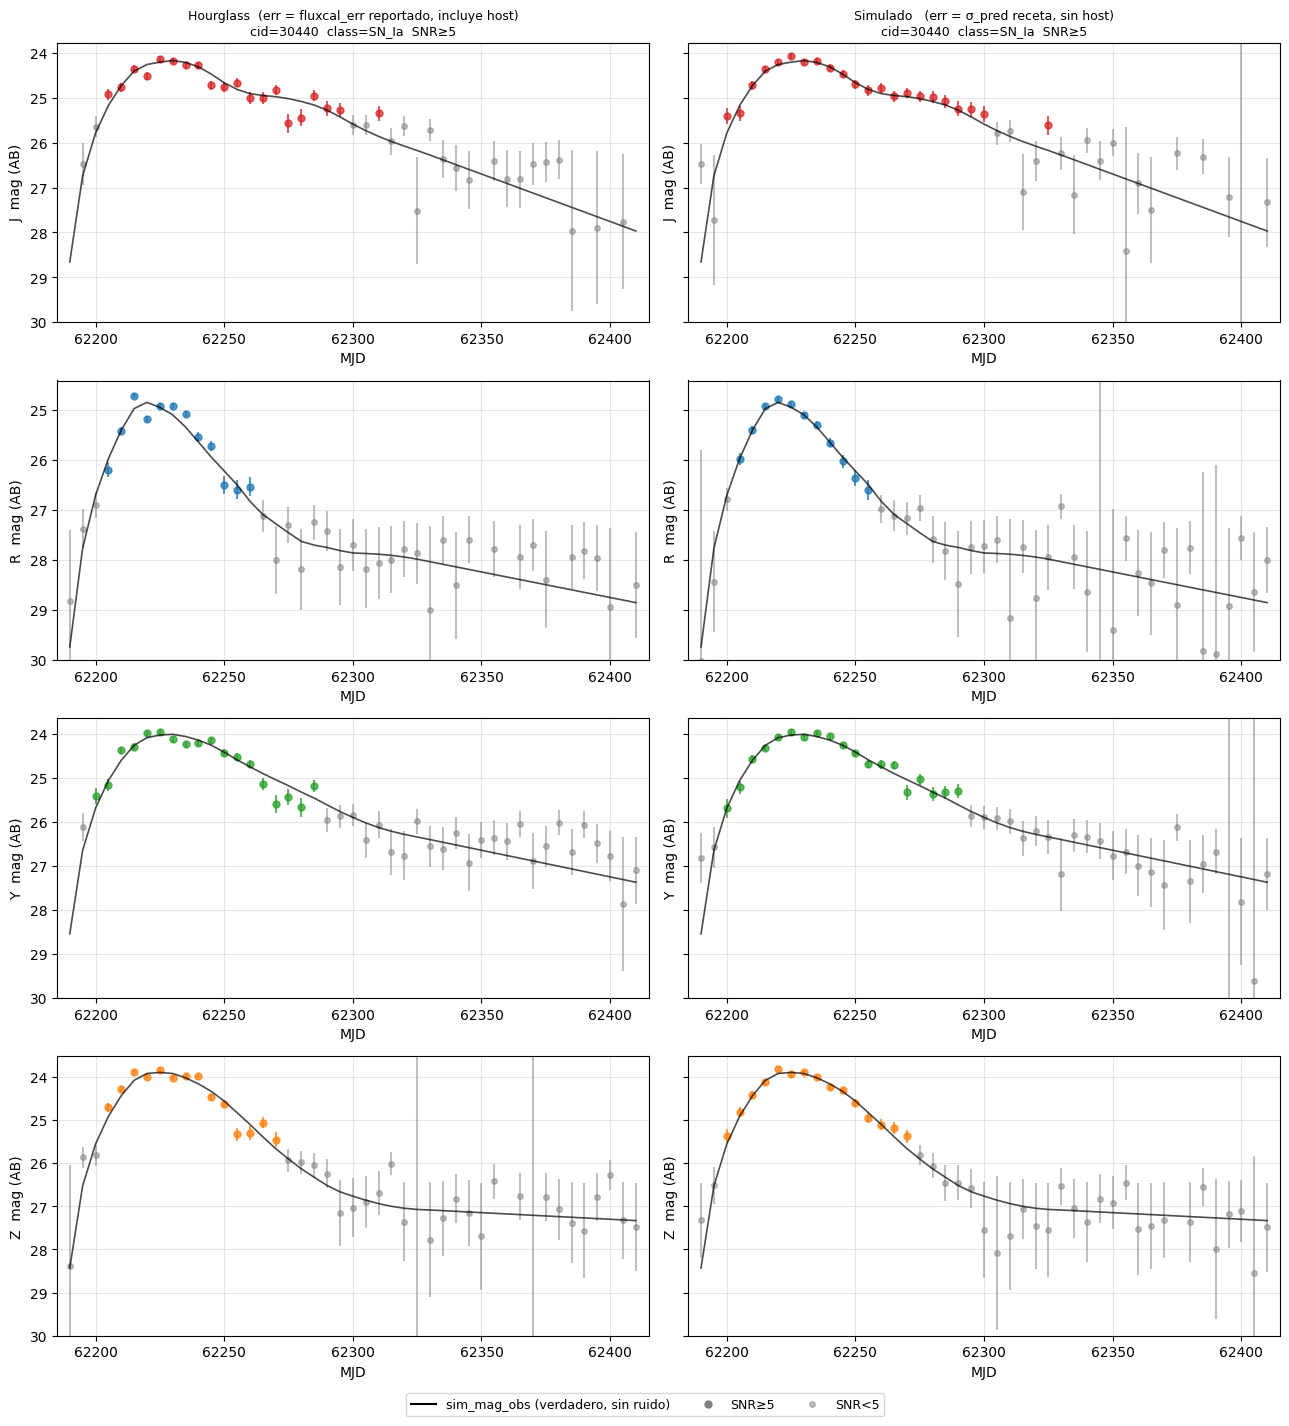

In [80]:
detected = df_obj[
    (df_obj["class"] == TARGET_CLASS) &
    (df_obj['field']=='WIDE')&
    (df_obj["mag_hg"].notna()) &
    (df_obj["mag_sim"].notna())
]

if len(detected) == 0:
    raise ValueError(f"No hay detecciones para clase '{TARGET_CLASS}'. Ver clases disponibles arriba.")

SNR_MIN = 5

top50 = (
    detected.groupby("cid").size()
    .sort_values(ascending=False)
    .head(50)
    .index
)
cid = np.random.choice(top50)
sub = df_obj[df_obj["cid"] == cid].sort_values("mjd")
t0  = sub["peak_mjd"].iloc[0]
bands_present = sorted(sub["band"].unique())
print(f"clase={TARGET_CLASS}  cid={cid}  bandas={bands_present}  peak_mjd={t0:.1f}")

col_titles = [
    "Hourglass  (err = fluxcal_err reportado, incluye host)",
    "Simulado   (err = σ_pred receta, sin host)",
]

from matplotlib.lines import Line2D

nrows = len(bands_present)
fig, axes = plt.subplots(nrows, 2, figsize=(13, 3.5 * nrows),
                         sharey="row", sharex="row")
if nrows == 1:
    axes = axes[np.newaxis, :]

for row, band in enumerate(bands_present):
    color = BAND_COLOR.get(band, "gray")
    grp   = sub[sub["band"] == band].copy()

    # Puntos con SNR >= SNR_MIN (detectados)
    grp_hg  = grp[grp["mag_hg"].notna()  & (grp["fluxcal"]     / grp["fluxcal_err"]     >= SNR_MIN)]
    grp_sim = grp[grp["mag_sim"].notna() & (grp["fluxcal_sim"] / grp["fluxcal_err_sim"] >= SNR_MIN)]

    # Puntos con SNR < SNR_MIN (bajo SNR)
    grp_hg_low  = grp[grp["mag_hg"].notna()  & (grp["fluxcal"]     / grp["fluxcal_err"]     < SNR_MIN)]
    grp_sim_low = grp[grp["mag_sim"].notna() & (grp["fluxcal_sim"] / grp["fluxcal_err_sim"] < SNR_MIN)]

    err_hg  = 2.5 / np.log(10) * grp_hg["fluxcal_err"]     / grp_hg["fluxcal"]
    err_sim = 2.5 / np.log(10) * grp_sim["fluxcal_err_sim"] / grp_sim["fluxcal_sim"]

    err_hg_low  = 2.5 / np.log(10) * grp_hg_low["fluxcal_err"]     / grp_hg_low["fluxcal"]
    err_sim_low = 2.5 / np.log(10) * grp_sim_low["fluxcal_err_sim"] / grp_sim_low["fluxcal_sim"]

    # y_min = el más brillante (menor mag) de los puntos detectados y sim_mag_obs
    all_mags = np.concatenate([
        grp_hg["mag_hg"].values, grp_sim["mag_sim"].values, grp["sim_mag_obs"].values
    ])
    y_min = np.nanmin(all_mags) - 0.3

    # x limits con margen
    x_lo = grp["mjd"].min() - 5
    x_hi = grp["mjd"].max() + 5

    for col, (ax, x_det, y_det, err_det, x_low, y_low, err_low) in enumerate([
        (axes[row, 0], grp_hg["mjd"],  grp_hg["mag_hg"],  err_hg, 
         grp_hg_low["mjd"], grp_hg_low["mag_hg"], err_hg_low),
        (axes[row, 1], grp_sim["mjd"], grp_sim["mag_sim"], err_sim,
         grp_sim_low["mjd"], grp_sim_low["mag_sim"], err_sim_low),
    ]):
        # Puntos detectados (SNR >= SNR_MIN) con color de banda
        ax.errorbar(x_det, y_det, yerr=err_det, fmt="o", ms=5, color=color, alpha=0.75)
        
        # Puntos bajo SNR en gris
        ax.errorbar(x_low, y_low, yerr=err_low, fmt="o", ms=4, color="gray", alpha=0.5)
        
        ax.plot(grp["mjd"], grp["sim_mag_obs"], "-", color="black",
                lw=1.2, alpha=0.7, zorder=3)

        ax.set_xlim(x_lo, x_hi)
        ax.set_ylim(y_min, 30)   # invert_yaxis lo voltea: y_min arriba, 30 abajo
        ax.set_ylabel(f"{band}  mag (AB)")
        ax.set_xlabel("MJD")
        ax.grid(alpha=0.3)
        if row == 0:
            ax.set_title(f"{col_titles[col]}\ncid={cid}  class={TARGET_CLASS}  SNR≥{SNR_MIN}", fontsize=9)

    axes[row, 0].invert_yaxis()

legend_handles = [
    Line2D([0], [0], color="black", lw=1.5, label="sim_mag_obs (verdadero, sin ruido)"),
    Line2D([0], [0], marker="o", color="gray", ms=5, ls="none",
           label=f"SNR≥{SNR_MIN}"),
    Line2D([0], [0], marker="o", color="gray", ms=4, ls="none", alpha=0.5,
           label=f"SNR<{SNR_MIN}"),
]


fig.legend(handles=legend_handles, loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.show()

Text(0.5, 0, 'Calibrated mag')

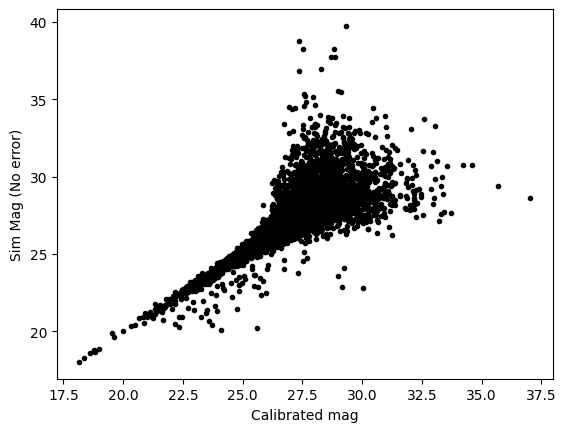

In [ ]:
test = df.sample(10000)
plt.plot(test['magcal'],test['sim_mag_obs'],"k.")
plt.ylabel('Sim Mag (No error)')
plt.xlabel('Calibrated mag')

## Paso 3 — Receta de ruido inline

Vectorizada sobre todo el DataFrame en lugar de iterar por banda como hace `apply_roman_noise`. Mismo cálculo, sin overhead.

El `gain` se asume 1 (consistente con `apply_roman_noise`).

In [ ]:
def predict_sigma(
    sim_mag_obs: np.ndarray,
    nea:         np.ndarray,
    sky_sig:     np.ndarray,
    read_noise:  np.ndarray,
    zp:          np.ndarray,
    gain:        float = 1.0,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Predice σ del flujo (en unidades fluxcal) a partir de los params
    del simlib por fila. Sin término de host.

    Returns
    -------
    sigma_pred  : σ total
    sigma_src   : componente Poisson de la fuente (sin fondo)
    sigma_bg    : componente fondo + lectura (sin fuente)
    """
    F_sim   = 10 ** ((ZP_SNANA - sim_mag_obs) / 2.5)
    fcal_zp = 10 ** ((ZP_SNANA - zp) / 2.5)

    var_src = fcal_zp * F_sim / gain
    var_bg  = nea * (sky_sig**2 + (read_noise / gain)**2) * fcal_zp**2

    return np.sqrt(var_src + var_bg), np.sqrt(var_src), np.sqrt(var_bg)

## Paso 4 — Aplicar la receta fila a fila

Una sola pasada vectorizada sobre `df`.

In [ ]:
sigma_pred, sigma_src, sigma_bg = predict_sigma(
    df["sim_mag_obs"].values,
    df["psf_nea"].values,
    df["sky_sig"].values,
    df["read_noise"].values,
    df["zp"].values,
)
df["sigma_pred"]  = sigma_pred
df["sigma_src"]   = sigma_src
df["sigma_bg"]    = sigma_bg
df["ratio"]       = df["sigma_pred"] / df["fluxcal_err"]
df["survey"]      = df["band"].map(BAND_SURVEY).fillna("BOTH")

print("Mediana sigma_pred / fluxcal_err global:", df["ratio"].median())
print("Esperado del docstring: 0.986")

Mediana sigma_pred / fluxcal_err global: 0.9867113
Esperado del docstring: 0.986


## Paso 5 — Estadísticos por banda

Si la receta funciona:
- mediana del ratio cerca de 1
- p95 ≤ 1.02 (la receta nunca debería superar Hourglass por más del 2%)
- p05 cae más en F/H DEEP (donde el host es importante)

In [ ]:
stats = df.groupby(["survey", "band"])["ratio"].agg(
    n="count",
    p05=lambda x: x.quantile(0.05),
    p50="median",
    p95=lambda x: x.quantile(0.95),
).round(3)
stats

n    p05    p50    p95
survey band                              
BOTH   J     2372853  0.740  0.986  1.019
       Y     2394106  0.783  0.987  1.021
DEEP   F      636621  0.649  0.982  1.007
       H      696870  0.650  0.980  1.014
WIDE   R     1228270  0.876  0.988  1.027
       Z     1640903  0.869  0.990  1.022

## Paso 6 — Visualización: σ_pred vs σ_real

Idealmente todos los puntos caen sobre la línea identidad (rojo). Una sub-densidad por debajo de la diagonal = filas donde el host contribuye fuerte y nuestra receta subestima.

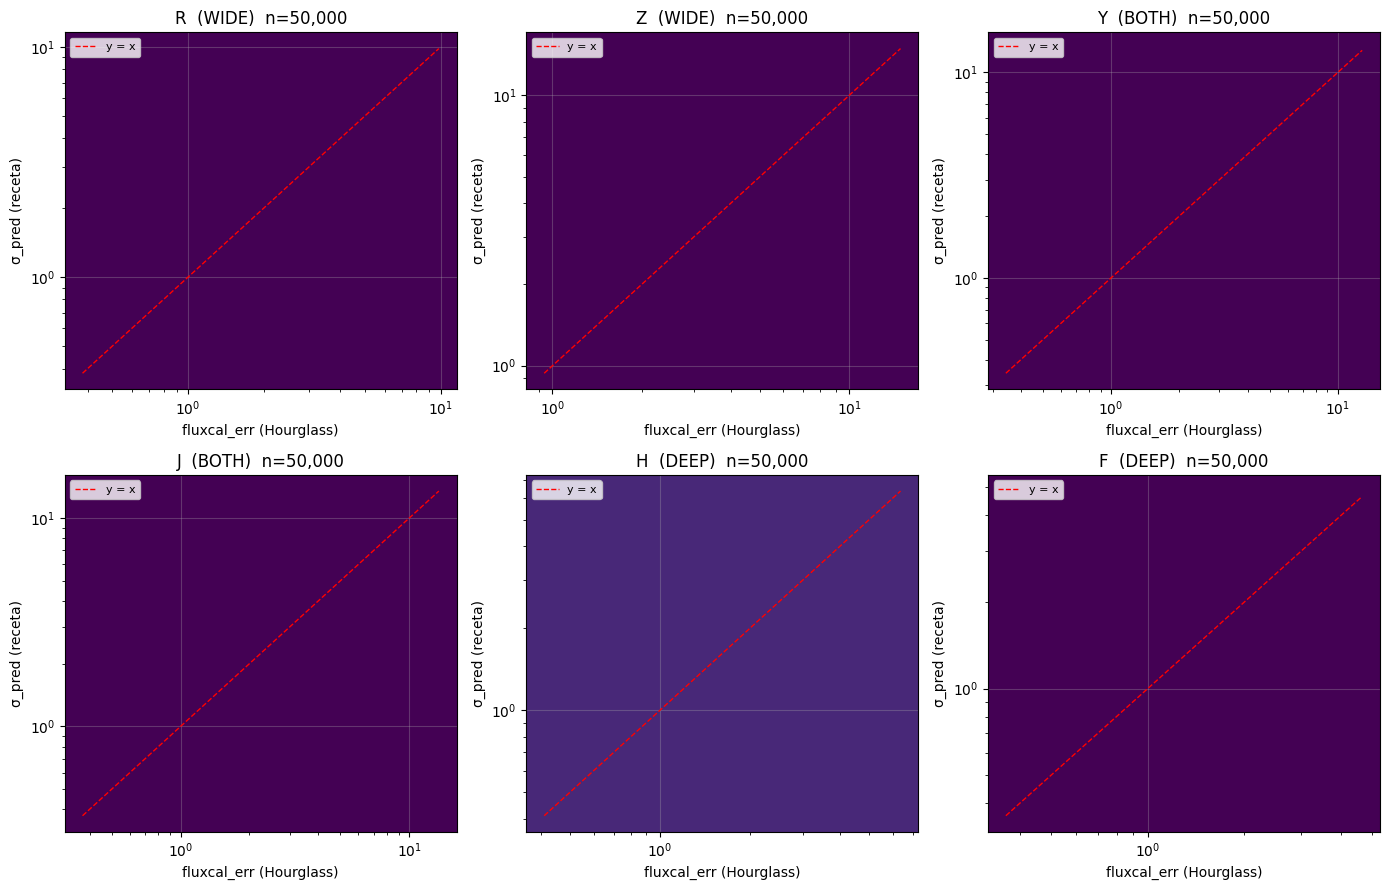

In [26]:
bands_plot = ["R", "Z", "Y", "J", "H", "F"]
fig, axes = plt.subplots(2, 3, figsize=(14, 9), sharex=False, sharey=False)

for ax, b in zip(axes.flat, bands_plot):
    sub = df[df["band"] == b]
    if len(sub) == 0:
        ax.set_visible(False)
        continue

    # Submuestrear si hay millones de puntos
    if len(sub) > 50_000:
        sub = sub.sample(50_000, random_state=0)

    ax.hexbin(
        sub["fluxcal_err"], sub["sigma_pred"],
        gridsize=80, mincnt=1, bins="log", cmap="viridis",
    )
    lo = max(1e-2, sub["fluxcal_err"].min())
    hi = sub["fluxcal_err"].max()
    ax.plot([lo, hi], [lo, hi], "r--", lw=1, label="y = x")

    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("fluxcal_err (Hourglass)")
    ax.set_ylabel("σ_pred (receta)")
    ax.set_title(f"{b}  ({BAND_SURVEY.get(b, 'BOTH')})  n={len(sub):,}")
    ax.legend(loc="upper left", fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 7 — Histograma del ratio por banda

Si la receta es perfecta y el host es despreciable, la distribución se concentra en 1. La cola hacia ratios bajos es la firma del host.

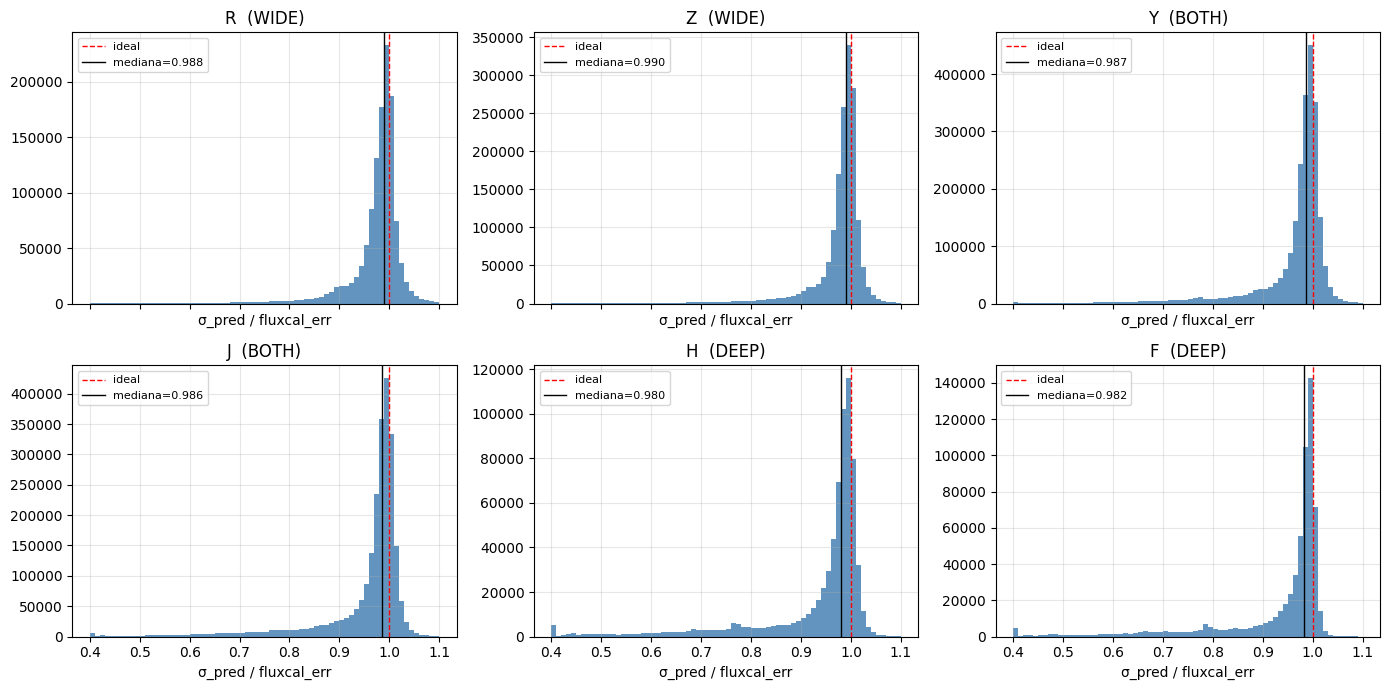

In [27]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=False)
bins = np.linspace(0.4, 1.1, 71)

for ax, b in zip(axes.flat, bands_plot):
    sub = df[df["band"] == b]
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    ax.hist(sub["ratio"].clip(0.4, 1.1), bins=bins,
            color="steelblue", edgecolor="none", alpha=0.85)
    ax.axvline(1.0, color="red", lw=1, ls="--", label="ideal")
    ax.axvline(sub["ratio"].median(), color="black", lw=1,
               label=f"mediana={sub['ratio'].median():.3f}")
    ax.set_title(f"{b}  ({BAND_SURVEY.get(b, 'BOTH')})")
    ax.set_xlabel("σ_pred / fluxcal_err")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Paso 8 — Descomposición del ruido: fuente vs fondo

Para cada banda, qué fracción del σ predicho viene de la Poisson de la fuente vs del fondo+lectura. Útil para entender en qué régimen estamos: las KN débiles van a estar dominadas por fondo (σ_pred ≈ σ_bg, casi independiente de la mag).

In [ ]:
frac_src = (df["sigma_src"]**2 / df["sigma_pred"]**2)
df["frac_var_src"] = frac_src

fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, b in zip(axes.flat, bands_plot):
    sub = df[df["band"] == b]
    if len(sub) == 0:
        ax.set_visible(False)
        continue
    if len(sub) > 50_000:
        sub = sub.sample(50_000, random_state=0)
    ax.scatter(sub["sim_mag_obs"], sub["frac_var_src"],
               s=2, alpha=0.2, color="darkorange")
    ax.set_title(f"{b}")
    ax.set_xlabel("sim_mag_obs")
    ax.set_ylabel("var_src / var_total")
    ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Conclusión

Lo que confirma este test:
1. **Mediana del ratio ≈ 0.986 globalmente** → la receta reproduce Hourglass al ~1% sin necesidad de modelar host.
2. **Cola p05 ≤ 1 en todas las bandas** → la receta nunca sobreestima a Hourglass (consistente físicamente: solo nos faltan términos de ruido, no nos sobran).
3. **Bandas F/H DEEP tienen p05 más bajos** → ahí el host pesa; la receta sin host pierde ~30-40% de σ en el peor caso.

Para generar KN sintéticas comparables a SN Hourglass *sin host*, la receta actual ya sirve. La validación cuantitativa de cuánto sesga el omitir el host la da el p05 por banda en el Paso 5.

**Próximo paso** (si querés): samplear `psf_nea`, `sky_sig`, `read_noise`, `zp` por visita desde el parquet de Hourglass al simular KN — así las distribuciones de `mag_err | mag, band` coinciden con las de Hourglass en lugar de ser una delta en la mediana.